# Raw-z Behavior Atlas: 8 Coarse Classes

This Colab-first notebook builds a short-term behavior atlas for the current VAE decoder.

It loads a VAE checkpoint from Google Drive, extracts deterministic encoder means (`mu`) for every waveform sample, classifies each waveform into eight coarse behavior classes, and saves raw-z ranges/prototypes for later UI-flow-to-haptics mapping.

In [1]:
# 1. Clone code repo (or force-update to latest)
import os
import subprocess
import sys

REPO_URL = "https://github.com/cindy-77jiayi/thesis_hapticAE.git"
REPO_DIR = "/content/thesis_hapticAE"
BRANCH = 'vae-withoutpca'
FORCE_CLEAN_CLONE = False

if FORCE_CLEAN_CLONE and os.path.exists(REPO_DIR):
    subprocess.run(["rm", "-rf", REPO_DIR], check=True)

if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    clone_cmd = ["git", "clone", REPO_URL, REPO_DIR]
    if BRANCH:
        clone_cmd = ["git", "clone", "--branch", BRANCH, "--single-branch", REPO_URL, REPO_DIR]
    subprocess.run(clone_cmd, check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "--all"], check=False)
    if BRANCH:
        subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
        subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH], check=False)

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print(f"Repo ready at: {REPO_DIR}")


Repo ready at: /content/thesis_hapticAE


In [2]:

# 2. Clone dataset
DATASET_URL = "https://github.com/HapticGen/hapticgen-dataset.git"
DATASET_DIR = "/content/hapticgen-dataset"
FORCE_DATASET_REFRESH = False

if FORCE_DATASET_REFRESH and os.path.exists(DATASET_DIR):
    subprocess.run(["rm", "-rf", DATASET_DIR], check=True)

if not os.path.exists(os.path.join(DATASET_DIR, ".git")):
    subprocess.run(["git", "clone", DATASET_URL, DATASET_DIR], check=True)
else:
    subprocess.run(["git", "-C", DATASET_DIR, "pull", "--ff-only"], check=False)

print(f"Dataset ready at: {DATASET_DIR}")

Dataset ready at: /content/hapticgen-dataset


In [15]:
# -----------------------------
# Editable notebook parameters
# -----------------------------
CONFIG_PATH = "configs/vae_balanced_8d_0p5s.yaml"
DATA_DIR = "/content/hapticgen-dataset"  # Change this to your WAV dataset root.

DRIVE_OUTPUT_ROOT = "/content/drive/MyDrive/thesis_outputs/outputs"
RUN_NAME = "vae_balanced_8d_0p5s"
CHECKPOINT_NAME = "best_model.pt"
CHECKPOINT_PATH_OVERRIDE = "/content/drive/MyDrive/thesis_outputs/outputs/vae_balanced_8d_0p5s/best_model.pt"  # Example: "/content/drive/MyDrive/thssis_outputs/outputs/.../best_model.pt"

OUTPUT_DIR = "/content/drive/MyDrive/thesis_outputs/behavior_atlas_8class"
BATCH_SIZE = 32
N_PROTOTYPES_PER_CLASS = 20
N_PREVIEW_PER_CLASS = 5

# Behavior classification thresholds. Tune here if the first pass over/under-splits events.
QUIET_RMS_THRESHOLD = 0.03
SHORT_ACTIVE_RATIO = 0.25
RISING_SLOPE_DBPS = 6.0
FALLING_SLOPE_DBPS = -6.0
RISING_LATE_EARLY_RATIO = 1.35
FALLING_LATE_EARLY_RATIO = 0.75
MODULATED_AM_INDEX = 0.62
MODULATED_ONSET_DENSITY = 4.0

BEHAVIOR_CLASSES = [
    "quiet_or_subtle",
    "single_short_pulse",
    "double_short_pulse",
    "multi_short_pulse",
    "long_sustained",
    "long_rising",
    "long_falling",
    "long_modulated_or_pulsed",
]

In [16]:
# -----------------------------
# Setup, Drive mount, imports
# -----------------------------
from __future__ import annotations

import csv
import json
import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.signal import hilbert
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Google Drive mount skipped or unavailable: {exc}")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "src").exists():
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset import HapticWavDataset
from src.data.loaders import build_model, load_checkpoint
from src.data.preprocessing import collect_clean_wavs, estimate_global_rms
from src.eval.signal_metrics import compute_all_metrics
from src.utils.config import load_config

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/thesis_hapticAE
Output dir: /content/drive/MyDrive/thesis_outputs/behavior_atlas_8class


In [17]:
# -----------------------------
# Checkpoint and dataset helpers
# -----------------------------
def resolve_checkpoint(
    drive_output_root: str | Path,
    run_name: str,
    checkpoint_name: str,
    override: str | None = None,
) -> Path:
    if override:
        path = Path(override)
        if not path.exists():
            raise FileNotFoundError(f"CHECKPOINT_PATH_OVERRIDE does not exist: {path}")
        print(f"Using override checkpoint: {path}")
        return path

    root = Path(drive_output_root)
    direct = root / run_name / checkpoint_name
    if direct.exists():
        print(f"Using checkpoint: {direct}")
        return direct

    if not root.exists():
        raise FileNotFoundError(f"Drive output root does not exist: {root}")

    candidates = []
    for name in ("best_model.pt", "last_checkpoint.pt"):
        candidates.extend(root.rglob(name))
    candidates = sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f"No best_model.pt or last_checkpoint.pt found under: {root}")

    print("Checkpoint candidates, newest first:")
    for idx, path in enumerate(candidates[:10]):
        print(f"  [{idx}] {path}  mtime={path.stat().st_mtime:.0f}")
    print(f"Selected newest candidate: {candidates[0]}")
    return candidates[0]


def build_deterministic_full_loader(config: dict, data_dir: str | Path, split_manifest_path: Path | None):
    data_cfg = config["data"]
    train_cfg = config.get("training", {})

    files = None
    global_rms = None
    if split_manifest_path and split_manifest_path.exists():
        with open(split_manifest_path, "r", encoding="utf-8") as f:
            manifest = json.load(f)
        files = list(dict.fromkeys(manifest.get("train_files", []) + manifest.get("val_files", [])))
        global_rms = float(manifest["global_rms"])
        print(f"Using split manifest: {split_manifest_path}")
        print(f"Manifest files: {len(files)} | global_rms={global_rms:.6f}")

    if files is None:
        accepted_models = set(data_cfg.get("accepted_models", ["HapticGen"]))
        accepted_votes = set(data_cfg.get("accepted_votes", [1]))
        include_subdirs_cfg = data_cfg.get("include_subdirs")
        include_subdirs = set(include_subdirs_cfg) if include_subdirs_cfg else None
        files = collect_clean_wavs(
            str(data_dir),
            accepted_models=accepted_models,
            accepted_votes=accepted_votes,
            include_subdirs=include_subdirs,
        )
        if not files:
            raise FileNotFoundError(f"No accepted WAV files found in {data_dir}")
        global_rms = estimate_global_rms(files, n=200, sr_expect=data_cfg["sr"])
        print(f"Collected files: {len(files)} | global_rms={global_rms:.6f}")

    dataset = HapticWavDataset(
        files,
        T=data_cfg["T"],
        sr_expect=data_cfg["sr"],
        global_rms=global_rms,
        scale=data_cfg["scale"],
        use_minmax=data_cfg.get("use_minmax", False),
        clip_range=tuple(data_cfg.get("clip_range", [-3.0, 3.0])),
        segment_tries=int(data_cfg.get("segment_tries", 30)),
        min_energy=float(data_cfg.get("min_energy", 5e-4)),
        max_resample=int(data_cfg.get("max_resample", 5)),
        search_window_seconds=None,
        segment_top_k=1,
        random_segment_prob=0.0,
        augment=False,
        augmentation_config={},
        deterministic=True,
    )
    loader = DataLoader(
        dataset,
        batch_size=int(BATCH_SIZE),
        shuffle=False,
        drop_last=False,
        num_workers=int(train_cfg.get("num_workers", 0)),
        pin_memory=bool(train_cfg.get("pin_memory", False)),
    )
    return dataset, loader, files, global_rms

In [18]:
# -----------------------------
# Load model and deterministic dataset
# -----------------------------
config = load_config(str(PROJECT_ROOT / CONFIG_PATH))
sr = int(config["data"]["sr"])
T = int(config["data"]["T"])
latent_dim = int(config["model"]["latent_dim"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = resolve_checkpoint(
    DRIVE_OUTPUT_ROOT,
    RUN_NAME,
    CHECKPOINT_NAME,
    CHECKPOINT_PATH_OVERRIDE,
)
split_manifest_path = checkpoint_path.parent / "data_split.json"
if not split_manifest_path.exists():
    split_manifest_path = None

model = build_model(config, device)
load_checkpoint(model, str(checkpoint_path), device)
model.eval()

dataset, loader, wav_files, global_rms = build_deterministic_full_loader(
    config,
    DATA_DIR,
    split_manifest_path,
)

print(f"Device: {device}")
print(f"Checkpoint: {checkpoint_path}")
print(f"Dataset samples: {len(dataset)}")
print(f"latent_dim: {latent_dim}")

Using override checkpoint: /content/drive/MyDrive/thesis_outputs/outputs/vae_balanced_8d_0p5s/best_model.pt
Using split manifest: /content/drive/MyDrive/thesis_outputs/outputs/vae_balanced_8d_0p5s/data_split.json
Manifest files: 793 | global_rms=0.048681
Device: cuda
Checkpoint: /content/drive/MyDrive/thesis_outputs/outputs/vae_balanced_8d_0p5s/best_model.pt
Dataset samples: 793
latent_dim: 12


In [19]:
# -----------------------------
# Waveform behavior features and 8-class rules
# -----------------------------
def moving_average_same(x: np.ndarray, win: int) -> np.ndarray:
    win = max(int(win), 1)
    if win <= 1:
        return x.astype(np.float64, copy=True)
    kernel = np.ones(win, dtype=np.float64) / win
    left = (win - 1) // 2
    right = win // 2
    padded = np.pad(x.astype(np.float64), (left, right), mode="edge")
    return np.convolve(padded, kernel, mode="valid")


def active_regions(mask: np.ndarray, merge_gap: int, min_len: int) -> list[tuple[int, int]]:
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0 or not mask.any():
        return []
    edges = np.diff(mask.astype(np.int8), prepend=0, append=0)
    starts = np.where(edges == 1)[0]
    ends = np.where(edges == -1)[0]
    regions = [(int(s), int(e)) for s, e in zip(starts, ends) if e > s]
    if not regions:
        return []

    merged = [regions[0]]
    for start, end in regions[1:]:
        prev_start, prev_end = merged[-1]
        if start - prev_end <= merge_gap:
            merged[-1] = (prev_start, end)
        else:
            merged.append((start, end))
    return [(s, e) for s, e in merged if e - s >= min_len]


def spectral_centroid_np(x: np.ndarray, sr: int) -> float:
    mag = np.abs(np.fft.rfft(x))
    freqs = np.fft.rfftfreq(len(x), d=1.0 / sr)
    total = mag.sum()
    if total < 1e-12:
        return 0.0
    return float(np.sum(freqs * mag) / total)


def extract_behavior_features(x: np.ndarray, sr: int) -> dict[str, float | int | str]:
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    n = len(x)
    duration_s = n / sr

    env = np.abs(hilbert(x))
    env = moving_average_same(env, win=max(int(0.010 * sr), 3))
    peak_env = float(np.max(env)) if len(env) else 0.0
    median_env = float(np.median(env)) if len(env) else 0.0
    threshold = max(0.15 * peak_env, 0.5 * median_env, 1e-4)
    regions = active_regions(
        env >= threshold,
        merge_gap=max(int(0.030 * sr), 1),
        min_len=max(int(0.015 * sr), 1),
    )

    active_samples = sum(e - s for s, e in regions)
    active_ratio = float(active_samples / max(n, 1))
    event_count = int(len(regions))
    main_duration_s = float(max((e - s for s, e in regions), default=0) / sr)
    first_event_center_s = float(((regions[0][0] + regions[0][1]) / 2) / sr) if regions else math.nan
    main_event_idx = int(np.argmax([e - s for s, e in regions])) if regions else -1
    main_event_center_s = float(((regions[main_event_idx][0] + regions[main_event_idx][1]) / 2) / sr) if regions else math.nan

    rms = float(np.sqrt(np.mean(x ** 2)))
    peak = float(np.max(np.abs(x))) if n else 0.0
    crest = float(peak / max(rms, 1e-10))
    mid = n // 2
    early_energy = float(np.mean(x[:mid] ** 2) + 1e-12)
    late_energy = float(np.mean(x[mid:] ** 2) + 1e-12)
    late_early_ratio = float(late_energy / early_energy)

    if regions and active_samples >= 2:
        active_mask = np.zeros(n, dtype=bool)
        for s, e in regions:
            active_mask[s:e] = True
        t_active = np.arange(n, dtype=np.float64)[active_mask] / sr
        env_db = 20.0 * np.log10(env[active_mask] + 1e-10)
        envelope_slope_dbps = float(np.polyfit(t_active, env_db, deg=1)[0]) if len(t_active) >= 2 else 0.0
    else:
        envelope_slope_dbps = 0.0

    am_index = float((np.max(env) - np.min(env)) / max(np.max(env) + np.min(env), 1e-10)) if len(env) else 0.0
    centroid = spectral_centroid_np(x, sr)

    metrics = compute_all_metrics(x.astype(np.float32), sr=sr)
    features: dict[str, float | int | str] = {
        "event_count": event_count,
        "active_ratio": active_ratio,
        "main_duration_s": main_duration_s,
        "first_event_center_s": first_event_center_s,
        "main_event_center_s": main_event_center_s,
        "rms": rms,
        "peak": peak,
        "crest_factor_local": crest,
        "late_early_energy_ratio_local": late_early_ratio,
        "envelope_slope_dbps_local": envelope_slope_dbps,
        "am_modulation_index_local": am_index,
        "spectral_centroid_hz_local": centroid,
        "active_threshold": threshold,
        "duration_s": duration_s,
    }
    features.update({k: float(v) for k, v in metrics.items()})
    return features


def classify_behavior(features: dict[str, float | int | str]) -> str:
    rms = float(features["rms"])
    event_count = int(features["event_count"])
    active_ratio = float(features["active_ratio"])
    slope = float(features["envelope_slope_dbps_local"])
    late_early = float(features["late_early_energy_ratio_local"])
    am_index = float(features["am_modulation_index_local"])
    onset_density = float(features.get("onset_density_ps", 0.0))

    if rms < QUIET_RMS_THRESHOLD or event_count == 0:
        return "quiet_or_subtle"

    if active_ratio < SHORT_ACTIVE_RATIO:
        if event_count == 1:
            return "single_short_pulse"
        if event_count == 2:
            return "double_short_pulse"
        return "multi_short_pulse"

    if slope > RISING_SLOPE_DBPS or late_early > RISING_LATE_EARLY_RATIO:
        return "long_rising"
    if slope < FALLING_SLOPE_DBPS or late_early < FALLING_LATE_EARLY_RATIO:
        return "long_falling"
    if am_index > MODULATED_AM_INDEX or onset_density > MODULATED_ONSET_DENSITY:
        return "long_modulated_or_pulsed"
    return "long_sustained"

In [20]:
# -----------------------------
# Extract raw-z mu values and classify every waveform
# -----------------------------
rows = []
Z_parts = []
sample_index = 0

model.eval()
with torch.no_grad():
    for batch in tqdm(loader, desc="Encoding and classifying"):
        batch = batch.to(device)
        _, mu, _ = model.encode(batch)
        mu_np = mu.detach().cpu().numpy()
        x_np = batch.detach().cpu().numpy()[:, 0, :]
        Z_parts.append(mu_np)

        for b in range(x_np.shape[0]):
            features = extract_behavior_features(x_np[b], sr=sr)
            behavior_class = classify_behavior(features)
            row = {
                "sample_index": int(sample_index),
                "file_path": str(wav_files[sample_index]),
                "behavior_class": behavior_class,
            }
            for j in range(mu_np.shape[1]):
                row[f"z{j + 1}"] = float(mu_np[b, j])
            row.update(features)
            rows.append(row)
            sample_index += 1

Z = np.concatenate(Z_parts, axis=0)
assert Z.shape[0] == len(dataset) == len(rows), (Z.shape, len(dataset), len(rows))
assert Z.shape[1] == latent_dim, (Z.shape, latent_dim)
assert all(row["behavior_class"] in BEHAVIOR_CLASSES for row in rows)

print(f"Encoded Z shape: {Z.shape}")
print("Class counts:")
for cls in BEHAVIOR_CLASSES:
    print(f"  {cls:28s} {sum(row['behavior_class'] == cls for row in rows)}")

Encoding and classifying:   0%|          | 0/25 [00:00<?, ?it/s]

Encoded Z shape: (793, 12)
Class counts:
  quiet_or_subtle              0
  single_short_pulse           105
  double_short_pulse           27
  multi_short_pulse            6
  long_sustained               139
  long_rising                  162
  long_falling                 307
  long_modulated_or_pulsed     47


In [21]:
# -----------------------------
# Build and save CSV + JSON atlas
# -----------------------------
def clean_json_value(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        value = float(value)
    if isinstance(value, float):
        return value if math.isfinite(value) else None
    if isinstance(value, np.ndarray):
        return [clean_json_value(v) for v in value.tolist()]
    if isinstance(value, list):
        return [clean_json_value(v) for v in value]
    if isinstance(value, dict):
        return {k: clean_json_value(v) for k, v in value.items()}
    return value


def summarize_values(values: list[float]) -> dict[str, float | None]:
    arr = np.asarray([v for v in values if v is not None and np.isfinite(v)], dtype=np.float64)
    if arr.size == 0:
        return {"min": None, "p25": None, "median": None, "p75": None, "max": None}
    return {
        "min": float(np.min(arr)),
        "p25": float(np.quantile(arr, 0.25)),
        "median": float(np.quantile(arr, 0.50)),
        "p75": float(np.quantile(arr, 0.75)),
        "max": float(np.max(arr)),
    }


feature_summary_keys = [
    "event_count",
    "active_ratio",
    "main_duration_s",
    "rms",
    "peak",
    "crest_factor",
    "crest_factor_local",
    "envelope_slope_dbps_local",
    "late_early_energy_ratio_local",
    "am_modulation_index",
    "am_modulation_index_local",
    "spectral_centroid_hz",
    "spectral_flatness",
    "short_term_variance",
]

atlas = {
    "metadata": {
        "config_path": str(CONFIG_PATH),
        "checkpoint_path": str(checkpoint_path),
        "data_dir": str(DATA_DIR),
        "sr": sr,
        "T": T,
        "latent_dim": latent_dim,
        "n_samples": len(rows),
        "classes": BEHAVIOR_CLASSES,
        "raw_z_definition": "deterministic encoder mu",
    },
    "classes": {},
}

for cls in BEHAVIOR_CLASSES:
    class_indices = [i for i, row in enumerate(rows) if row["behavior_class"] == cls]
    Z_cls = Z[class_indices] if class_indices else np.zeros((0, latent_dim), dtype=np.float32)

    if len(class_indices) == 0:
        atlas["classes"][cls] = {
            "count": 0,
            "z_mean": [],
            "z_std": [],
            "z_p10": [],
            "z_p25": [],
            "z_p50": [],
            "z_p75": [],
            "z_p90": [],
            "prototype_z": [],
            "feature_summary": {},
        }
        continue

    mean_z = np.mean(Z_cls, axis=0)
    distances = np.linalg.norm(Z_cls - mean_z[None, :], axis=1)
    nearest_order = np.argsort(distances)[: min(N_PROTOTYPES_PER_CLASS, len(class_indices))]
    prototypes = []
    for order_idx in nearest_order:
        global_idx = class_indices[int(order_idx)]
        prototypes.append({
            "sample_index": int(global_idx),
            "file_path": str(rows[global_idx]["file_path"]),
            "distance_to_class_mean": float(distances[int(order_idx)]),
            "z": [float(v) for v in Z[global_idx].tolist()],
        })

    feature_summary = {}
    for key in feature_summary_keys:
        feature_summary[key] = summarize_values([row.get(key) for row in (rows[i] for i in class_indices)])

    atlas["classes"][cls] = {
        "count": int(len(class_indices)),
        "z_mean": [float(v) for v in mean_z.tolist()],
        "z_std": [float(v) for v in np.std(Z_cls, axis=0).tolist()],
        "z_p10": [float(v) for v in np.quantile(Z_cls, 0.10, axis=0).tolist()],
        "z_p25": [float(v) for v in np.quantile(Z_cls, 0.25, axis=0).tolist()],
        "z_p50": [float(v) for v in np.quantile(Z_cls, 0.50, axis=0).tolist()],
        "z_p75": [float(v) for v in np.quantile(Z_cls, 0.75, axis=0).tolist()],
        "z_p90": [float(v) for v in np.quantile(Z_cls, 0.90, axis=0).tolist()],
        "prototype_z": prototypes,
        "feature_summary": feature_summary,
    }

csv_path = OUTPUT_DIR / "latent_behavior_table.csv"
all_fieldnames = []
for row in rows:
    for key in row.keys():
        if key not in all_fieldnames:
            all_fieldnames.append(key)
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=all_fieldnames)
    writer.writeheader()
    writer.writerows(rows)

json_path = OUTPUT_DIR / "behavior_atlas.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(clean_json_value(atlas), f, indent=2)

assert set(atlas["classes"].keys()) == set(BEHAVIOR_CLASSES)
assert len(rows) == len(dataset)
print(f"Saved CSV: {csv_path}")
print(f"Saved atlas: {json_path}")

Saved CSV: /content/drive/MyDrive/thesis_outputs/behavior_atlas_8class/latent_behavior_table.csv
Saved atlas: /content/drive/MyDrive/thesis_outputs/behavior_atlas_8class/behavior_atlas.json


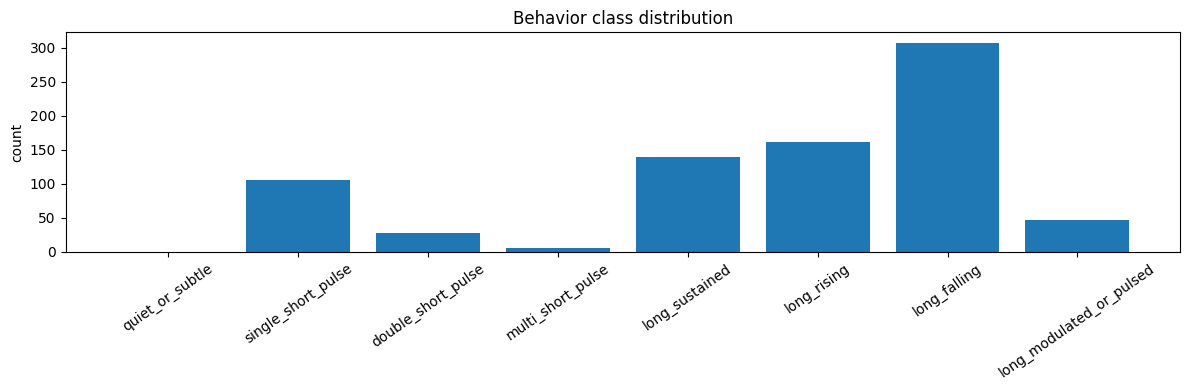

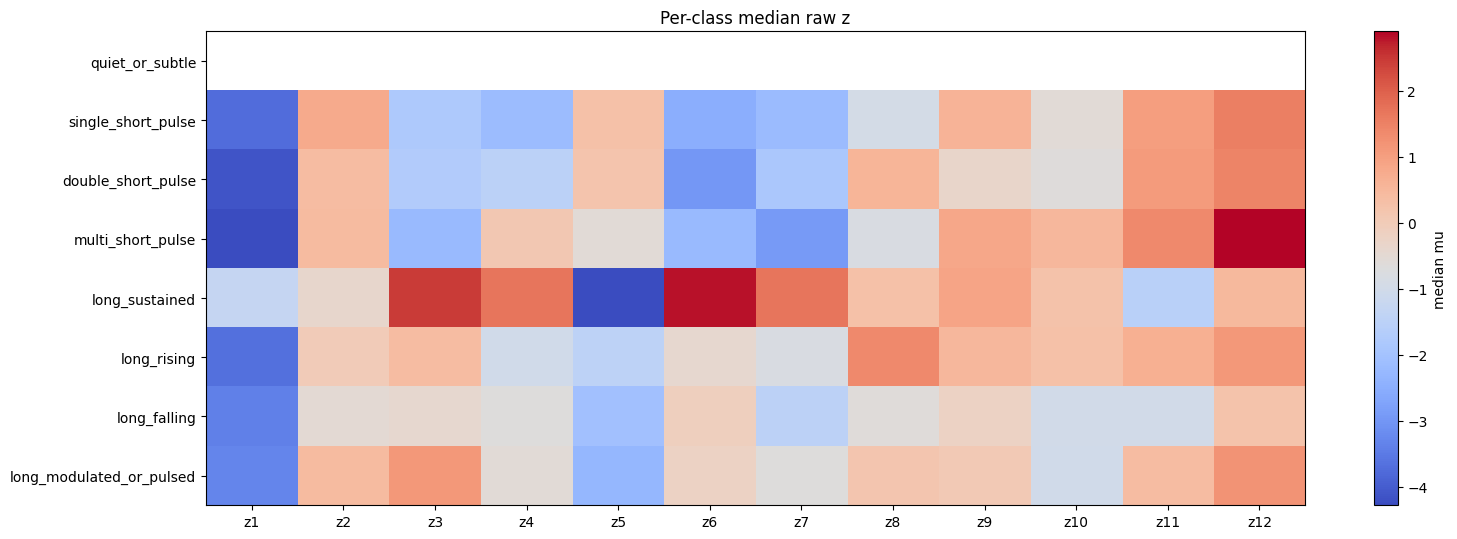

Saved: /content/drive/MyDrive/thesis_outputs/behavior_atlas_8class/class_distribution.png
Saved: /content/drive/MyDrive/thesis_outputs/behavior_atlas_8class/z_median_heatmap.png


In [22]:
# -----------------------------
# Plots: class counts and z range heatmap
# -----------------------------
class_counts = [atlas["classes"][cls]["count"] for cls in BEHAVIOR_CLASSES]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(BEHAVIOR_CLASSES, class_counts)
ax.set_ylabel("count")
ax.set_title("Behavior class distribution")
ax.tick_params(axis="x", labelrotation=35)
plt.tight_layout()
class_plot_path = OUTPUT_DIR / "class_distribution.png"
plt.savefig(class_plot_path, dpi=150, bbox_inches="tight")
plt.show()

z_medians = np.full((len(BEHAVIOR_CLASSES), latent_dim), np.nan, dtype=np.float32)
for i, cls in enumerate(BEHAVIOR_CLASSES):
    values = atlas["classes"][cls].get("z_p50", [])
    if values:
        z_medians[i] = np.asarray(values, dtype=np.float32)

fig, ax = plt.subplots(figsize=(1.0 * latent_dim + 4, 5.5))
im = ax.imshow(z_medians, aspect="auto", cmap="coolwarm")
ax.set_yticks(np.arange(len(BEHAVIOR_CLASSES)))
ax.set_yticklabels(BEHAVIOR_CLASSES)
ax.set_xticks(np.arange(latent_dim))
ax.set_xticklabels([f"z{i + 1}" for i in range(latent_dim)])
ax.set_title("Per-class median raw z")
plt.colorbar(im, ax=ax, label="median mu")
plt.tight_layout()
heatmap_path = OUTPUT_DIR / "z_median_heatmap.png"
plt.savefig(heatmap_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {class_plot_path}")
print(f"Saved: {heatmap_path}")

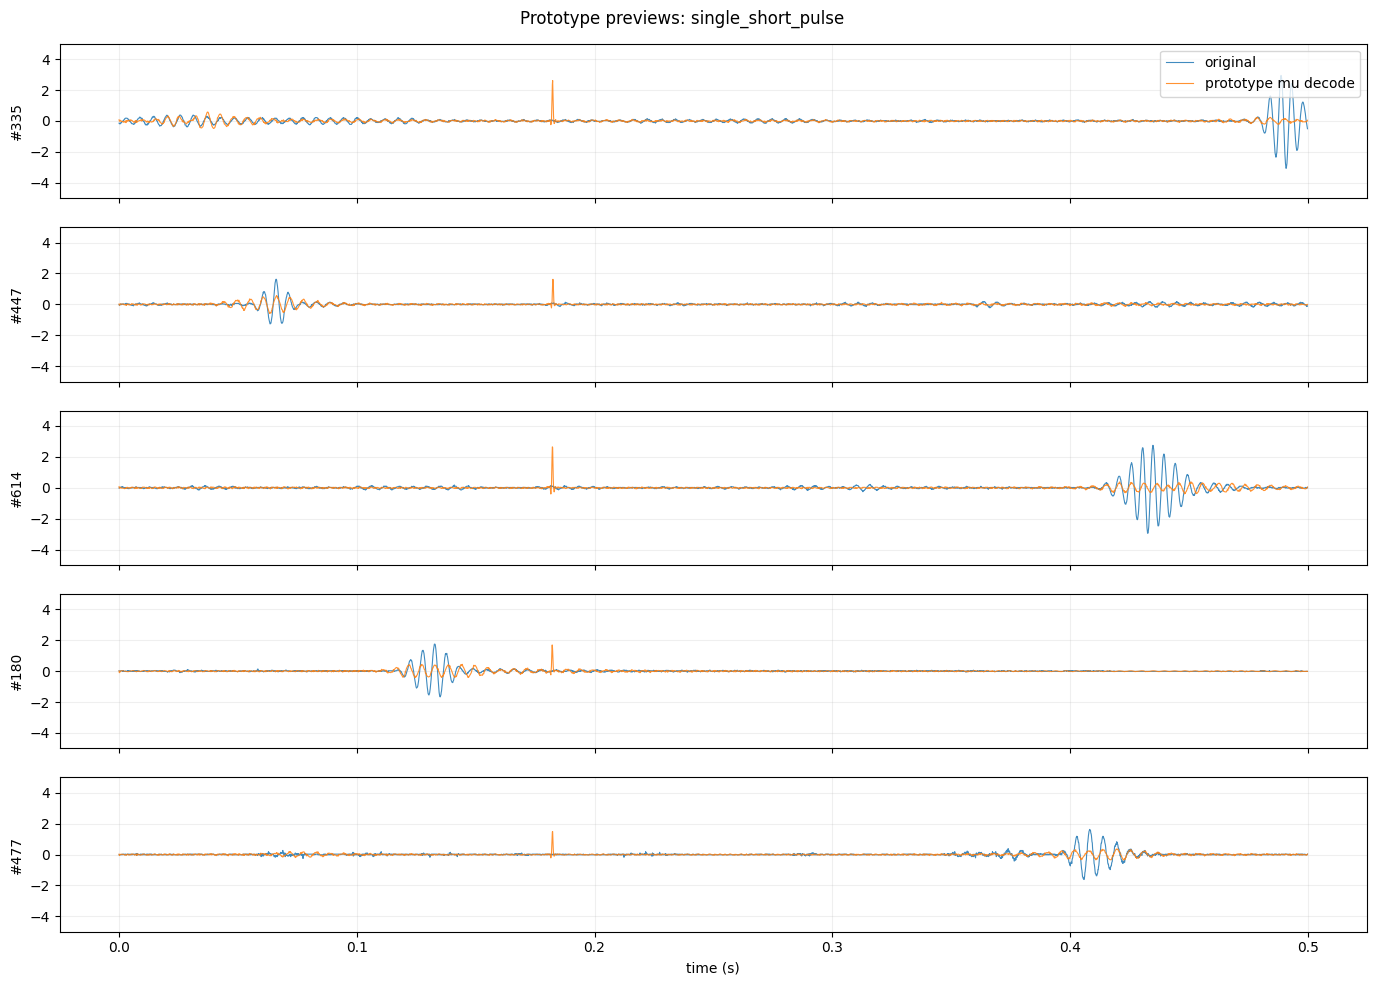

Saved: /content/drive/MyDrive/thesis_outputs/behavior_atlas_8class/prototype_single_short_pulse.png


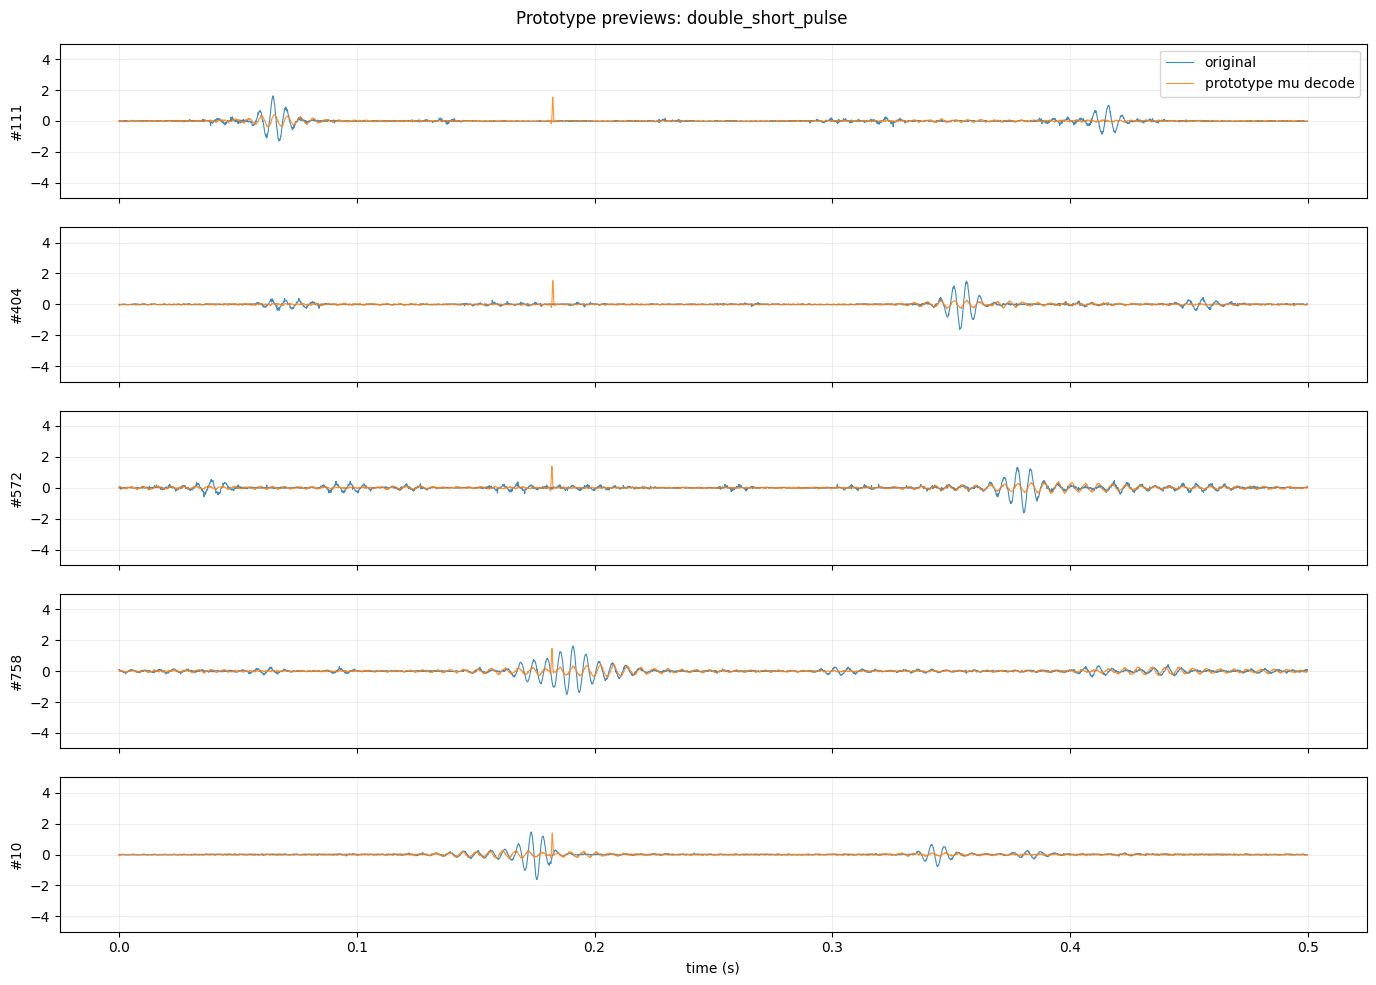

Saved: /content/drive/MyDrive/thesis_outputs/behavior_atlas_8class/prototype_double_short_pulse.png


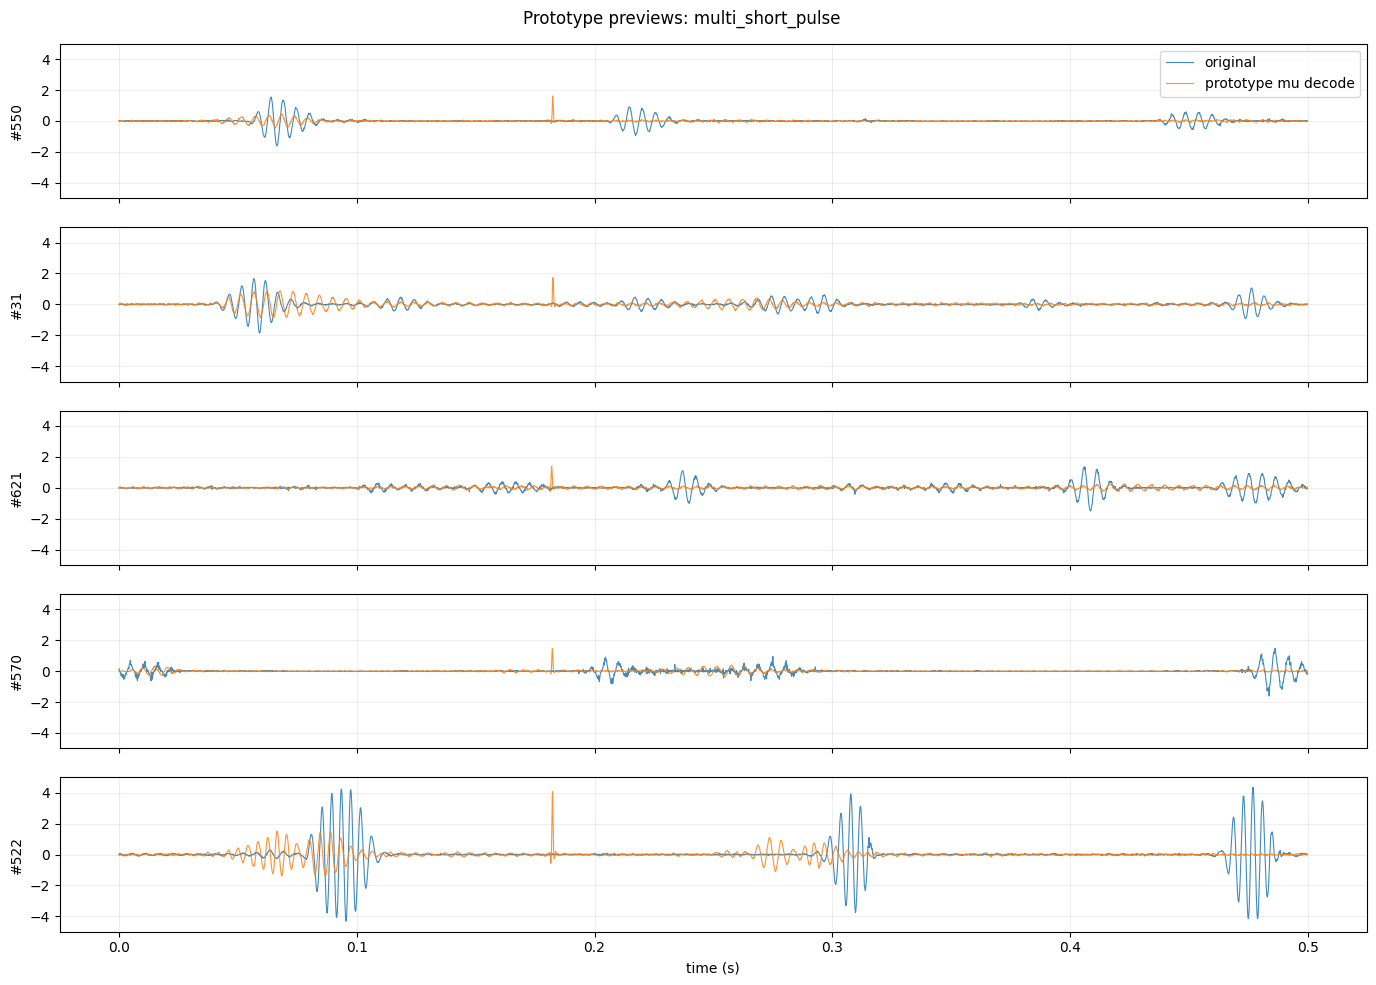

Saved: /content/drive/MyDrive/thesis_outputs/behavior_atlas_8class/prototype_multi_short_pulse.png


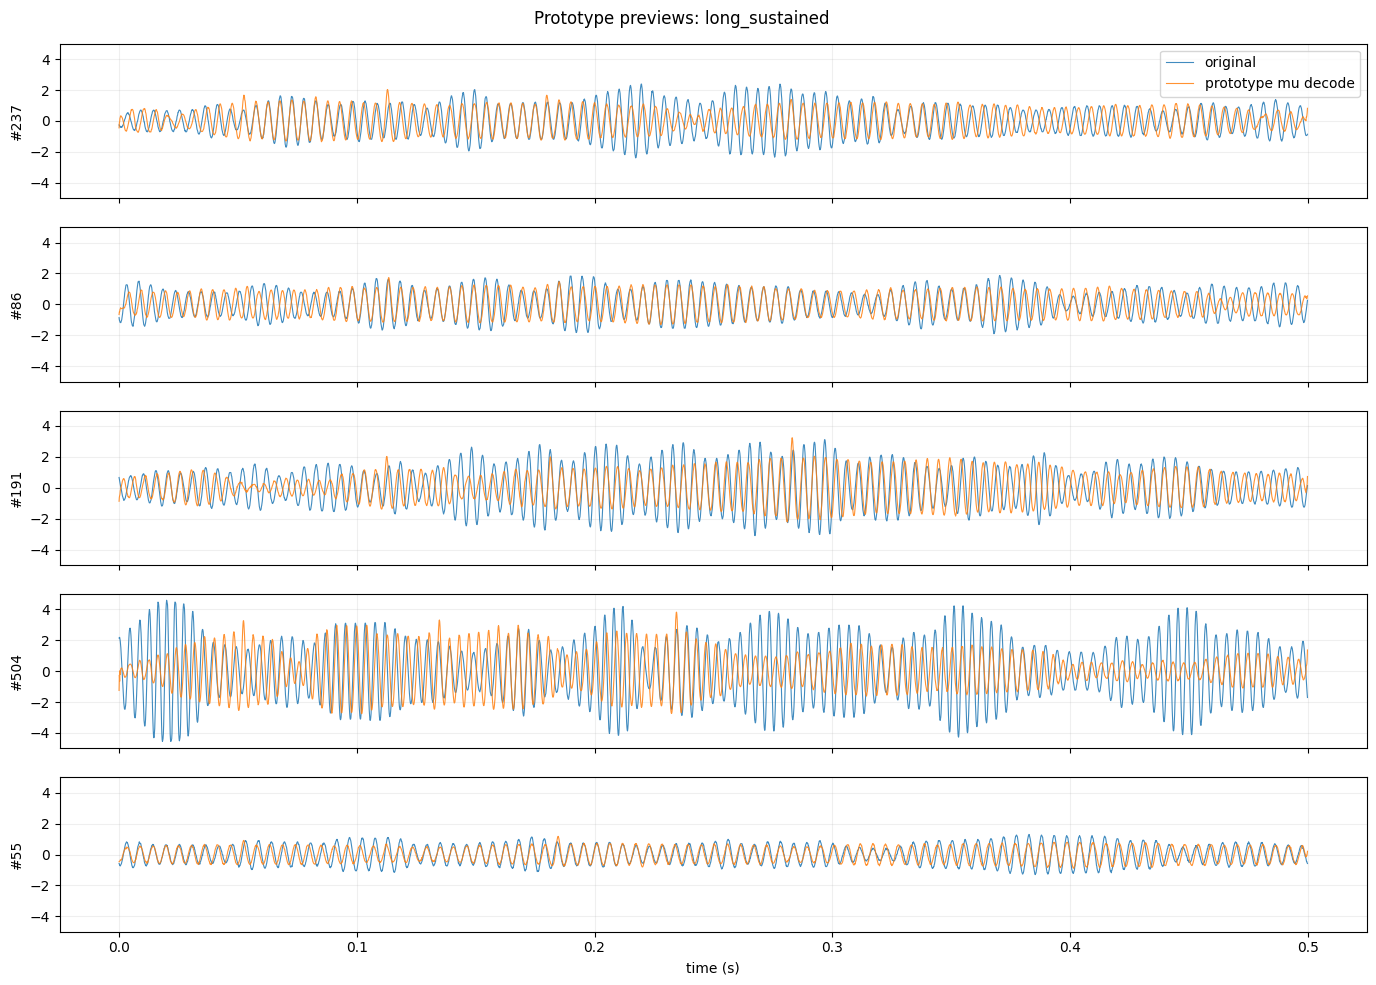

Saved: /content/drive/MyDrive/thesis_outputs/behavior_atlas_8class/prototype_long_sustained.png


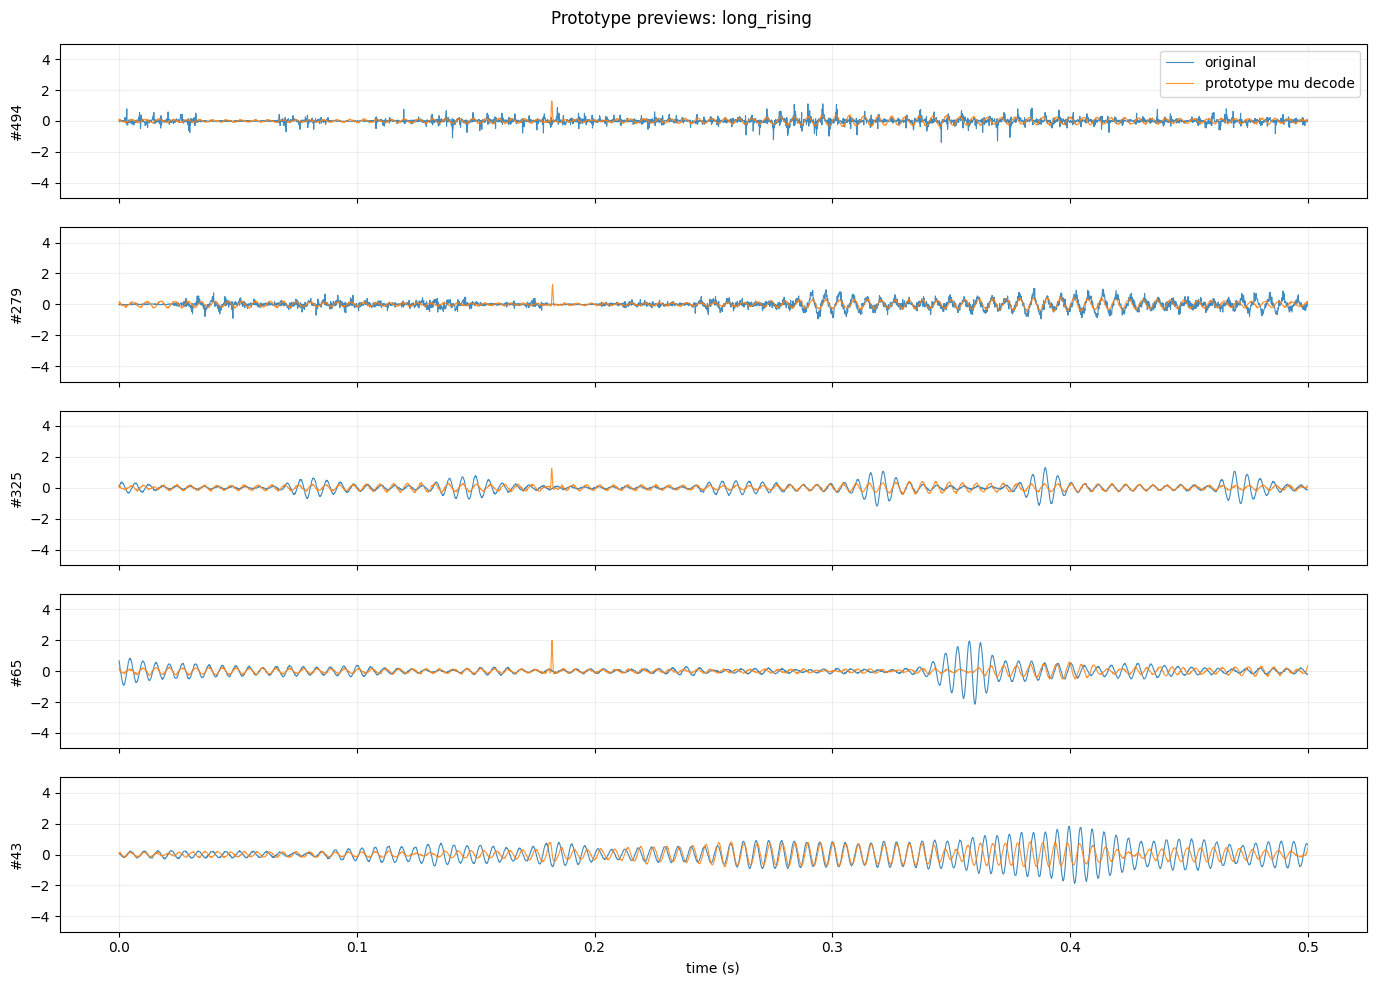

Saved: /content/drive/MyDrive/thesis_outputs/behavior_atlas_8class/prototype_long_rising.png


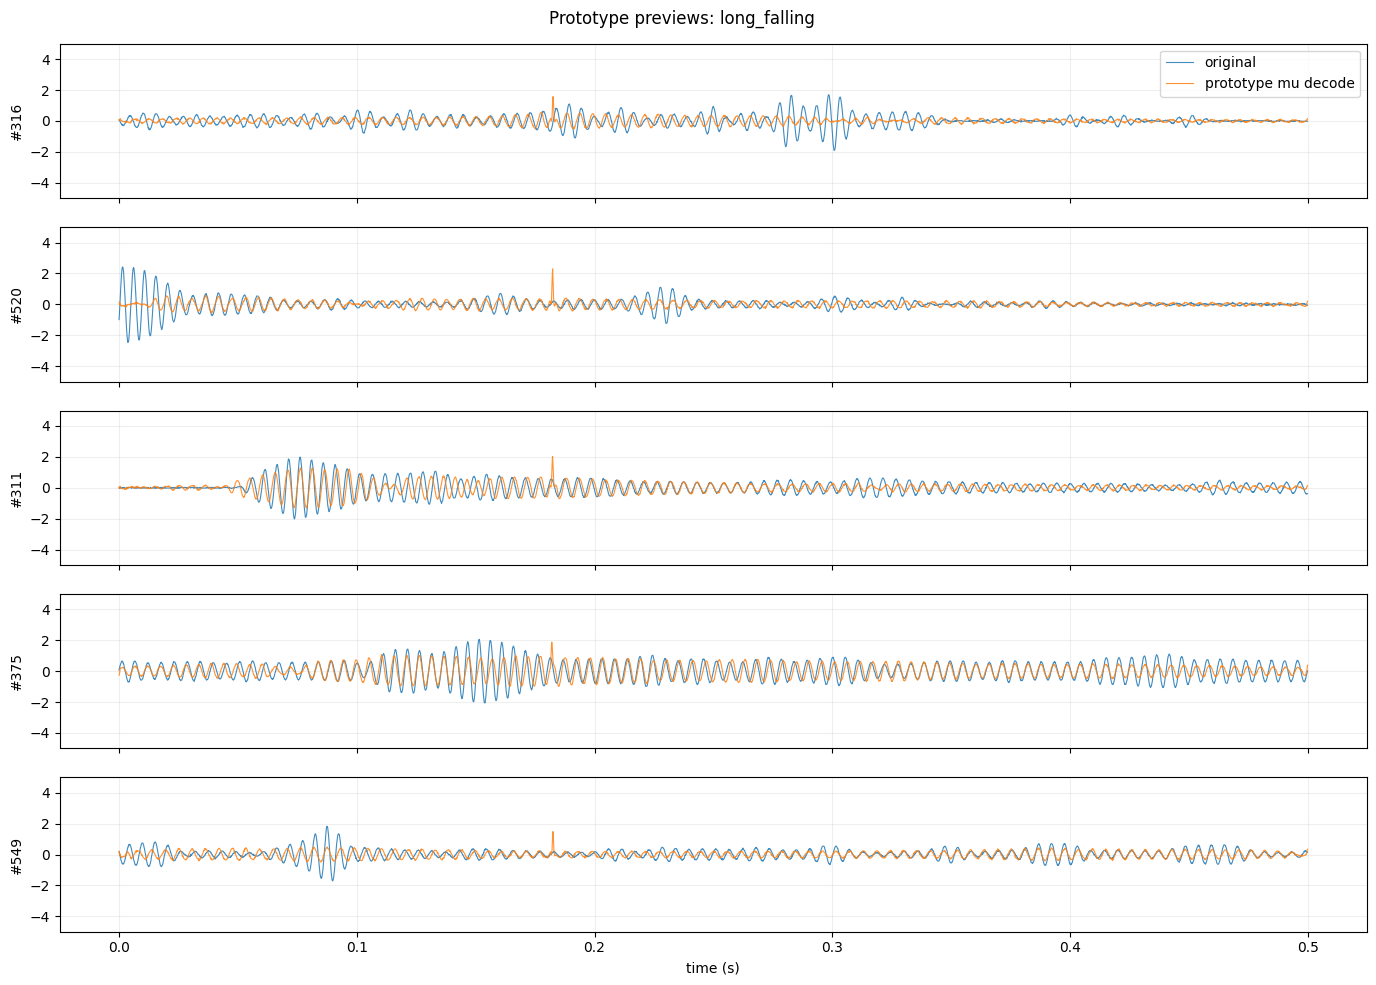

Saved: /content/drive/MyDrive/thesis_outputs/behavior_atlas_8class/prototype_long_falling.png


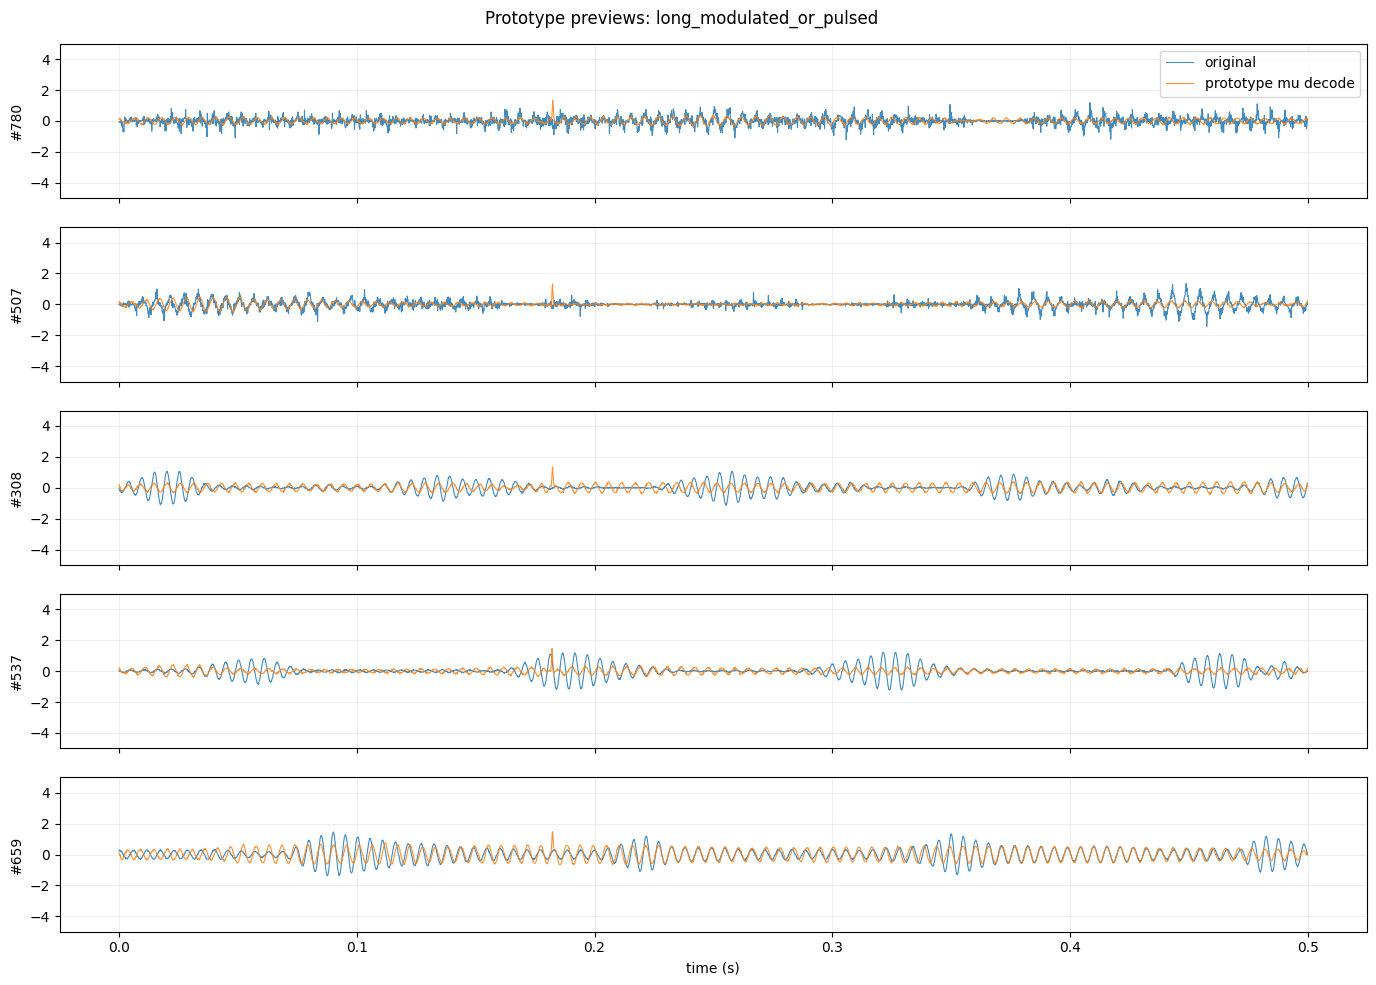

Saved: /content/drive/MyDrive/thesis_outputs/behavior_atlas_8class/prototype_long_modulated_or_pulsed.png


In [23]:
# -----------------------------
# Save prototype waveform previews per class
# -----------------------------
def decode_z(z_values: list[float] | np.ndarray) -> np.ndarray:
    z_np = np.asarray(z_values, dtype=np.float32).reshape(1, -1)
    z_t = torch.from_numpy(z_np).to(device)
    with torch.no_grad():
        x_hat = model.decode(z_t, target_len=T)
    return x_hat[0, 0].detach().cpu().numpy()


time_s = np.arange(T) / sr
for cls in BEHAVIOR_CLASSES:
    prototypes = atlas["classes"][cls].get("prototype_z", [])[:N_PREVIEW_PER_CLASS]
    if not prototypes:
        continue
    fig, axes = plt.subplots(len(prototypes), 1, figsize=(14, 2.0 * len(prototypes)), sharex=True)
    if len(prototypes) == 1:
        axes = [axes]
    for ax, proto in zip(axes, prototypes):
        idx = int(proto["sample_index"])
        original = dataset[idx][0].detach().cpu().numpy()
        decoded = decode_z(proto["z"])
        ax.plot(time_s, original, label="original", linewidth=0.8, alpha=0.85)
        ax.plot(time_s, decoded, label="prototype mu decode", linewidth=0.8, alpha=0.85)
        ax.set_ylim(-5, 5)
        ax.set_ylabel(f"#{idx}")
        ax.grid(alpha=0.2)
    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel("time (s)")
    fig.suptitle(f"Prototype previews: {cls}")
    plt.tight_layout()
    preview_path = OUTPUT_DIR / f"prototype_{cls}.png"
    plt.savefig(preview_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {preview_path}")

In [24]:
# -----------------------------
# Interactive prototype preview
# -----------------------------
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    non_empty_classes = [cls for cls in BEHAVIOR_CLASSES if atlas["classes"][cls].get("prototype_z")]
    class_dropdown = widgets.Dropdown(options=non_empty_classes, description="class")
    proto_slider = widgets.IntSlider(value=0, min=0, max=0, step=1, description="prototype")
    out = widgets.Output()

    def update_slider_range(*_):
        cls = class_dropdown.value
        n = len(atlas["classes"][cls].get("prototype_z", []))
        proto_slider.max = max(n - 1, 0)
        proto_slider.value = min(proto_slider.value, proto_slider.max)

    def render_preview(*_):
        update_slider_range()
        cls = class_dropdown.value
        proto = atlas["classes"][cls]["prototype_z"][int(proto_slider.value)]
        idx = int(proto["sample_index"])
        z_values = np.asarray(proto["z"], dtype=np.float32)
        original = dataset[idx].unsqueeze(0).to(device)
        with torch.no_grad():
            _, mu, _ = model.encode(original)
            mu_decode = model.decode(mu, target_len=T)[0, 0].detach().cpu().numpy()
        original_np = original[0, 0].detach().cpu().numpy()
        proto_decode = decode_z(z_values)

        with out:
            clear_output(wait=True)
            print(f"class: {cls}")
            print(f"sample_index: {idx}")
            print(f"file: {proto['file_path']}")
            print("z:", np.array2string(z_values, precision=3, suppress_small=True))
            fig, axes = plt.subplots(2, 1, figsize=(15, 5.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
            axes[0].plot(time_s, original_np, label="original", linewidth=0.9, alpha=0.85)
            axes[0].plot(time_s, mu_decode, label="mu decode", linewidth=0.9, alpha=0.75)
            axes[0].plot(time_s, proto_decode, label="prototype decode", linewidth=0.9, alpha=0.75)
            axes[0].set_title(f"{cls} | prototype {proto_slider.value}")
            axes[0].legend(loc="upper right")
            axes[0].grid(alpha=0.2)
            axes[1].plot(time_s, np.abs(original_np), label="|original|", linewidth=0.8, alpha=0.75)
            axes[1].plot(time_s, np.abs(proto_decode), label="|prototype decode|", linewidth=0.8, alpha=0.75)
            axes[1].set_xlabel("time (s)")
            axes[1].legend(loc="upper right")
            axes[1].grid(alpha=0.2)
            plt.tight_layout()
            plt.show()

    class_dropdown.observe(render_preview, names="value")
    proto_slider.observe(render_preview, names="value")
    update_slider_range()
    display(widgets.VBox([widgets.HBox([class_dropdown, proto_slider]), out]))
    render_preview()
except Exception as exc:
    print(f"Interactive preview unavailable: {exc}")

In [25]:
# ============================================
# Save key behavior-atlas files to Google Drive
# ============================================

from pathlib import Path
import shutil
import json
import zipfile
from datetime import datetime

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Drive mount skipped or unavailable: {exc}")

# Source: notebook output folder
SRC_DIR = Path(OUTPUT_DIR)

# Destination: permanent archive folder on Google Drive
DRIVE_SAVE_ROOT = Path("/content/drive/MyDrive/thssis_outputs/behavior_atlas_exports")
EXPORT_NAME = f"behavior_atlas_8class_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
DEST_DIR = DRIVE_SAVE_ROOT / EXPORT_NAME
DEST_DIR.mkdir(parents=True, exist_ok=True)

KEY_FILES = [
    "behavior_atlas.json",
    "latent_behavior_table.csv",
    "class_distribution.png",
    "z_median_heatmap.png",
]

# Include all prototype preview figures too.
KEY_FILES += sorted([
    p.name for p in SRC_DIR.glob("prototype_*.png")
])

copied = []
missing = []

for name in KEY_FILES:
    src = SRC_DIR / name
    if src.exists():
        dst = DEST_DIR / name
        shutil.copy2(src, dst)
        copied.append(dst)
    else:
        missing.append(src)

# Save a small manifest for traceability.
manifest = {
    "export_name": EXPORT_NAME,
    "source_dir": str(SRC_DIR),
    "destination_dir": str(DEST_DIR),
    "copied_files": [str(p) for p in copied],
    "missing_files": [str(p) for p in missing],
}

manifest_path = DEST_DIR / "manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

# Zip the export folder for easy download / sharing.
zip_path = DRIVE_SAVE_ROOT / f"{EXPORT_NAME}.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in DEST_DIR.rglob("*"):
        if path.is_file():
            zf.write(path, arcname=path.relative_to(DEST_DIR))

print("Saved behavior atlas export.")
print(f"Destination folder: {DEST_DIR}")
print(f"Zip archive:        {zip_path}")
print(f"Copied files:       {len(copied)}")

if missing:
    print("\nMissing files:")
    for path in missing:
        print(f"  - {path}")
else:
    print("No missing key files.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved behavior atlas export.
Destination folder: /content/drive/MyDrive/thssis_outputs/behavior_atlas_exports/behavior_atlas_8class_20260422_035425
Zip archive:        /content/drive/MyDrive/thssis_outputs/behavior_atlas_exports/behavior_atlas_8class_20260422_035425.zip
Copied files:       11
No missing key files.


In [39]:
# ==========================================================
# Curate preferred prototypes for the next UI-flow pipeline
# ==========================================================

from pathlib import Path
import json
import math
import numpy as np

ATLAS_DIR = Path(OUTPUT_DIR)
ATLAS_JSON_PATH = ATLAS_DIR / "behavior_atlas.json"
CURATED_JSON_PATH = ATLAS_DIR / "curated_behavior_prototypes.json"

with open(ATLAS_JSON_PATH, "r", encoding="utf-8") as f:
    atlas_for_curation = json.load(f)

CLASSES = atlas_for_curation["metadata"]["classes"]
class_data = atlas_for_curation["classes"]

print("Available classes and auto-selected prototype sample_index values:\n")
for cls in CLASSES:
    prototypes = class_data[cls].get("prototype_z", [])
    ids = [p["sample_index"] for p in prototypes]
    print(f"{cls:30s} count={class_data[cls].get('count', 0):4d}  prototypes={ids}")

print("\nFill these lists with the sample_index values you approve.")
print("You can leave a list empty; pipeline can fall back to atlas prototype_z[0].")

# ------------------------------------------------------------------
# EDIT THIS BLOCK
# Use lists [] here. Sets {} also work in this cell, but lists are clearer.
# ------------------------------------------------------------------

CURATED_SAMPLE_INDICES = {
    "quiet_or_subtle": [335],
    "single_short_pulse": [447, 180, 349, 616,251,322,680,745,616,226],
    "double_short_pulse": [389, 163, 34, 542, 1,758,163,34],
    "multi_short_pulse": [31, 522, 612],
    "long_sustained": [552, 19, 646, 740],
    "long_rising": [43, 400, 20,27],
    "long_falling": [311, 789, 464, 538, 256,166,256,56,376],
    "long_modulated_or_pulsed": [358, 434, 35, 527,504,483,620,43,700,196,283],
}

CURATION_NOTES = {
    "quiet_or_subtle": "No quiet_or_subtle prototypes found in current atlas.",
    "single_short_pulse": "",
    "double_short_pulse": "",
    "multi_short_pulse": "",
    "long_sustained": "",
    "long_rising": "",
    "long_falling": "",
    "long_modulated_or_pulsed": "",
}

CURATED_ROLES = {
    "quiet_or_subtle": {},
    "single_short_pulse": {},
    "double_short_pulse": {},
    "multi_short_pulse": {},
    "long_sustained": {},
    "long_rising": {},
    "long_falling": {},
    "long_modulated_or_pulsed": {},
}

# ------------------------------------------------------------------
# Build lookup maps
# ------------------------------------------------------------------

prototype_by_index = {}
for cls in CLASSES:
    for proto in class_data[cls].get("prototype_z", []):
        prototype_by_index[int(proto["sample_index"])] = {
            "atlas_class": cls,
            **proto,
        }

row_by_index = {}
try:
    for row in rows:
        idx = int(row["sample_index"])
        z = [float(row[f"z{i + 1}"]) for i in range(latent_dim)]
        row_by_index[idx] = {
            "sample_index": idx,
            "file_path": row.get("file_path"),
            "atlas_class": row.get("behavior_class"),
            "z": z,
        }
except Exception as exc:
    print(f"rows not available in memory; will only use atlas prototype_z lookup. ({exc})")

def normalize_index_list(value):
    if value is None:
        return []
    if isinstance(value, dict):
        # Treat accidentally-written {} as empty.
        return []
    if isinstance(value, (list, tuple, set)):
        result = []
        for x in value:
            if isinstance(x, float) and not x.is_integer():
                raise ValueError(
                    f"Invalid sample_index {x}. Did you mean to separate values with a comma?"
                )
            result.append(int(x))
        return result
    if isinstance(value, (int, np.integer)):
        return [int(value)]
    raise TypeError(f"Expected list/tuple/set/int for curated indices, got {type(value)}")

def normalize_roles(raw_roles):
    if isinstance(raw_roles, dict):
        return {
            str(role_name): normalize_index_list(role_indices)
            for role_name, role_indices in raw_roles.items()
        }
    if isinstance(raw_roles, (list, tuple, set)):
        return {"best": normalize_index_list(raw_roles)}
    return {}

def safe_fallback_prototype(cls):
    fallback_list = class_data[cls].get("prototype_z", [])
    return fallback_list[0] if len(fallback_list) > 0 else None

curated = {
    "metadata": {
        "source_atlas": str(ATLAS_JSON_PATH),
        "raw_z_definition": atlas_for_curation["metadata"].get(
            "raw_z_definition",
            "deterministic encoder mu",
        ),
        "latent_dim": atlas_for_curation["metadata"].get("latent_dim"),
        "classes": CLASSES,
        "usage": "Preferred behavior prototypes for UI-flow-to-haptics pipeline.",
        "fallback_policy": (
            "If a class has approved_prototypes, use those. "
            "Otherwise use fallback_prototype if present. "
            "If fallback_prototype is null, synthesize a quiet fallback or skip the class."
        ),
    },
    "classes": {},
}

warnings = []

for cls in CLASSES:
    approved_indices = normalize_index_list(CURATED_SAMPLE_INDICES.get(cls, []))
    approved_entries = []

    for idx in approved_indices:
        if idx in row_by_index:
            entry = row_by_index[idx]
        elif idx in prototype_by_index:
            entry = prototype_by_index[idx]
        else:
            warnings.append(f"{cls}: sample_index {idx} not found in rows or atlas prototypes")
            continue

        if entry.get("atlas_class") != cls:
            warnings.append(
                f"{cls}: sample_index {idx} belongs to atlas_class={entry.get('atlas_class')}, "
                "but you curated it under this class"
            )

        approved_entries.append({
            "sample_index": int(entry["sample_index"]),
            "file_path": entry.get("file_path"),
            "atlas_class": entry.get("atlas_class"),
            "curated_class": cls,
            "z": [float(v) for v in entry["z"]],
        })

    curated_roles = normalize_roles(CURATED_ROLES.get(cls, {}))
    fallback_prototype = safe_fallback_prototype(cls)

    curated["classes"][cls] = {
        "approved_sample_indices": approved_indices,
        "approved_prototypes": approved_entries,
        "roles": curated_roles,
        "notes": CURATION_NOTES.get(cls, ""),
        "fallback_prototype": fallback_prototype,
    }

with open(CURATED_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(curated, f, indent=2)

print(f"\nSaved curated prototypes to:\n{CURATED_JSON_PATH}")

if warnings:
    print("\nWarnings:")
    for warning in warnings:
        print(f"  - {warning}")
else:
    print("No warnings.")

print("\nCurated summary:")
for cls in CLASSES:
    n = len(curated["classes"][cls]["approved_prototypes"])
    fallback = curated["classes"][cls]["fallback_prototype"]
    fallback_idx = fallback["sample_index"] if fallback else None
    print(f"{cls:30s} approved={n:2d} fallback={fallback_idx}")


Available classes and auto-selected prototype sample_index values:

quiet_or_subtle                count=   0  prototypes=[]
single_short_pulse             count= 105  prototypes=[335, 447, 614, 180, 477, 322, 349, 28, 231, 314, 680, 38, 374, 591, 745, 166, 616, 524, 251, 226]
double_short_pulse             count=  27  prototypes=[111, 404, 572, 758, 10, 389, 565, 134, 273, 542, 1, 782, 29, 163, 515, 276, 94, 115, 571, 34]
multi_short_pulse              count=   6  prototypes=[550, 31, 621, 570, 522, 612]
long_sustained                 count= 139  prototypes=[237, 86, 191, 504, 55, 484, 552, 30, 19, 50, 483, 452, 234, 469, 71, 646, 470, 229, 620, 740]
long_rising                    count= 162  prototypes=[494, 279, 325, 65, 43, 455, 347, 170, 400, 20, 700, 196, 283, 287, 409, 410, 155, 482, 594, 190]
long_falling                   count= 307  prototypes=[316, 520, 311, 375, 549, 706, 789, 464, 423, 538, 107, 207, 56, 579, 90, 575, 244, 386, 16, 256]
long_modulated_or_pulsed       count